# Import required Libraries 

In [90]:
import numpy as np # Linear Algebra 
import pandas as pd # Data Preprocessing 
pd.set_option('display.max_columns', 59)
import matplotlib.pyplot as plt # Data visulization 
import seaborn as sns

### Reading the Data/Overview 
##### Based on intital overview of the file in excel removing columns: last_scraped, source, listing_url,scrape_id,name,description,neighborhood_overview,picture_url, host_url, host_name, host_location, host_about, host_thumbnail_url, host_picture_url,host_verifications, host_neighbourhood, neighbourhood,neighbourhood_group_cleansed,latitude, longitude, bathrooms_text,calendar_updated,license,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms (redundant with room_type + calculated_host_listings_count), availability_eoy (less standard, prefer the _30/_60/_90/_365 series), availability_eoy', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', estimated_revenue_l365d ( redundant)
#### Primary Business Question: What listing attributes, host characteristics, neighborhood factors, and guest review signals (volume and rating) most significantly influence Airbnb listing prices and guest satisfaction scores in Tokyo

In [91]:
df_listing = pd.read_csv('/users/yasmeenkarachiwala/downloads/MarketingAnalytics /listings.csv', sep = "," )                      

In [92]:
df = df_listing.drop(columns = ['last_scraped', 'source', 'listing_url','scrape_id','name','description','neighborhood_overview',
                               'picture_url', 'host_url', 'host_name', 'host_location','host_about', 'host_thumbnail_url', 'host_picture_url',
                               'host_verifications', 'host_neighbourhood', 'neighbourhood','neighbourhood_group_cleansed','latitude', 'longitude',
                              'bathrooms_text','calendar_updated','license','calculated_host_listings_count_entire_homes',
                              'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms'
                              ,'availability_eoy', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights',
                              'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'estimated_revenue_l365d'
                             ]
                            )

In [93]:
# How big is the data?
df.shape

(27945, 45)

In [94]:
# How does the data look?
# using sample instead of head or tail to avoid bais view from the dataset 
df.sample(5)

,id,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month
6212,607555146234752672,197405131,2018-06-22,within an hour,100%,100%,t,90.0,104.0,t,t,Toshima Ku,Entire rental unit,Entire home/apt,3,1.0,1.0,2.0,"[""Rice maker"", ""Hangers"", ""Room-darkening shad...","$15,969.00",1,28,t,7,16,22,100,2025-09-29,54,17,1,15,102,2022-12-30,2025-09-20,4.76,4.69,4.76,4.81,4.94,4.89,4.72,t,86,1.61
25868,1467520833991982069,700506638,2025-06-10,within an hour,100%,100%,f,13.0,13.0,t,t,Minato Ku,Private room in rental unit,Private room,2,0.5,1.0,1.0,"[""Shampoo"", ""Fire extinguisher"", ""Body soap"", ...","$11,315.00",1,90,t,19,48,78,170,2025-09-29,3,3,3,0,18,2025-09-05,2025-09-19,4.67,5.00,5.00,4.33,4.67,4.67,4.67,t,11,3.00
21513,1375185324687600198,557366491,2024-01-19,within an hour,100%,97%,t,49.0,103.0,t,t,Setagaya Ku,Entire rental unit,Entire home/apt,3,1.0,1.0,1.0,"[""Hangers"", ""Room-darkening shades"", ""Elevator...","$10,000.00",30,365,t,1,7,7,202,2025-09-29,1,1,0,0,60,2025-07-01,2025-07-01,4.00,5.00,5.00,5.00,4.00,5.00,5.00,f,49,0.33
27642,1507969350496231451,718472192,2025-09-11,within an hour,100%,100%,f,1.0,1.0,t,t,Sumida Ku,Entire home,Entire home/apt,16,2.0,4.0,10.0,"[""Children\u2019s books and toys for ages 0-2 ...","$17,915.00",3,365,t,12,33,51,326,2025-09-29,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,1,NaN
24733,1446227782062891647,258715948,2019-04-29,within an hour,100%,100%,f,6.0,6.0,t,t,Minato Ku,Entire rental unit,Entire home/apt,7,1.0,1.0,6.0,"[""Rice maker"", ""Drying rack for clothing"", ""Ho...","$18,532.00",1,50,t,19,34,56,83,2025-09-29,2,2,1,0,12,2025-08-18,2025-09-12,5.00,4.50,5.00,5.00,5.00,5.00,5.00,t,6,1.40


In [95]:
# What are the data types ?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27945 non-null  int64  
 1   host_id                         27945 non-null  int64  
 2   host_since                      27937 non-null  object 
 3   host_response_time              27244 non-null  object 
 4   host_response_rate              27244 non-null  object 
 5   host_acceptance_rate            27525 non-null  object 
 6   host_is_superhost               25929 non-null  object 
 7   host_listings_count             27937 non-null  float64
 8   host_total_listings_count       27937 non-null  float64
 9   host_has_profile_pic            27937 non-null  object 
 10  host_identity_verified          27937 non-null  object 
 11  neighbourhood_cleansed          27945 non-null  object 
 12  property_type                   

In [96]:
# Are there any duplicates?
# zero duplicates 
df.duplicated().sum()

np.int64(0)

In [97]:
# How many values are missing?
missing = df.isnull().sum()/df['id'].count() *100

In [98]:
missing.sort_values(ascending = False)

review_scores_communication       14.088388
review_scores_location            14.088388
review_scores_cleanliness         14.088388
review_scores_checkin             14.088388
review_scores_value               14.088388
review_scores_accuracy            14.088388
review_scores_rating              14.084809
first_review                      14.084809
reviews_per_month                 14.084809
last_review                       14.084809
price                              8.820898
bathrooms                          8.813741
beds                               8.799427
host_is_superhost                  7.214171
host_response_time                 2.508499
host_response_rate                 2.508499
host_acceptance_rate               1.502952
bedrooms                           1.102165
has_availability                   0.425836
host_since                         0.028628
host_has_profile_pic               0.028628
host_total_listings_count          0.028628
host_listings_count             

## Cleaning/formatting 
#### Host Category 
##### host_since → engineer to host_tenure_days,host_is_superhost, host_identity_verified, host_has_profile_pic,host_response_time, host_response_rate, host_acceptance_rate, host_listings_count or host_total_listings_count (pick one; they're correlated — use calculated_host_listings_count as it's more reliable)
#### Listing Category
##### room_type, property_type, accommodates, bedrooms, bathrooms, beds, minimum_nights, maximum_nights, amenities — requires parsing (count amenities or use multi-hot encoding),instant_bookable
#### Review Category 
##### number_of_reviews, number_of_reviews_ltm, reviews_per_month, All review_scores_* sub-scores (accuracy, cleanliness, checkin, communication, location, value), first_review, last_review → engineer to listing_age_days, days_since_last_review
#### Neighborhood
##### neighbourhood_cleansed — encode as dummy/ordinal after aggregating rare categories
#### Availability
##### availability_30, availability_60, availability_90, availability_365, estimated_occupancy_l365d
### Before looking into association/correlation moving on to cleaning the data to ensure the variables are in correct format 
#### Step 1 converting price to float, missing values will be represented by Nan (not a number)
##### daily price in local currency i.e yen the dollar sign is default due to formatting 
##### Since price is target variable, the missing values should not be replaced by mean or median since it will skew the statistical output

In [99]:
df['price'].head(5)

0    $12,600.00
1    $10,459.00
2    $33,671.00
3    $24,143.00
4     $8,795.00
Name: price, dtype: object

In [100]:
df['price'] = df['price'].str.replace(r'[$]','',regex = True)

In [101]:
df['price'] = df['price'].str.replace(r',','',regex = True)

In [102]:
df['price'] = pd.to_numeric(df['price'], errors = 'coerce')

In [103]:
df['price']

0        12600.0
1        10459.0
2        33671.0
3        24143.0
4         8795.0
          ...   
27940    27102.0
27941    34200.0
27942    18896.0
27943    23040.0
27944    32847.0
Name: price, Length: 27945, dtype: float64

#### Step 2 converting % to numeric columns 

In [104]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str.replace('%', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

#### Step 3 converting boolean columns to Nominal i.e 0/1

In [105]:
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 
             'host_identity_verified', 'instant_bookable', 'has_availability']

df[bool_cols] = df[bool_cols].replace({'t': 1, 'f': 0})

/var/folders/n3/g3ljtrsx6kq6g77d8q1d7yy00000gn/T/ipykernel_10708/2209589408.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[bool_cols] = df[bool_cols].replace({'t': 1, 'f': 0})


#### Step 4 count amenities 

In [106]:
import ast
df['count_amenities'] = df['amenities'].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0
)

## Missing Values 
##### For regression model, -->
##### run two versions one with all listings, one filtered to has_reviews == 1 only.
##### The unreviewed listings will skew satisfaction analysis.


In [107]:
df['price'].dtype

dtype('float64')

In [108]:
df['price'].isna().sum()

np.int64(2465)

In [109]:
df.shape

(27945, 46)

In [110]:
# These are missing because the listing has never been reviewed — 
# that's meaningful information, not a data error. 
# Imputing here would be fabricating reviews that don't exist.

In [111]:
# Filling with zero for unreviewed listing 
df['has_review'] = df['review_scores_accuracy'].notna().astype(int)
review_cols = ['review_scores_accuracy', 'review_scores_communication', 'review_scores_location', 
                'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_value', 'review_scores_rating' 
               , 'reviews_per_month'
              ]
df[review_cols] = df[review_cols].fillna(0)

In [112]:
df['bedrooms'].describe()

count    27637.000000
mean         1.422188
std          1.062763
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         50.000000
Name: bedrooms, dtype: float64

In [113]:
df[df['bedrooms']>30]
# Bedrooms with 35,36, and 50 which are accomodating 1,3 seems erroneous data 
# removing those rows 

,id,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month,count_amenities,has_review
671,17600334,12014384,2014-02-07,NaN,NaN,71.0,0.0,19.0,53.0,1.0,1.0,Arakawa Ku,Private room in rental unit,Private room,3,6.0,36.0,50.0,"[""Pets allowed"", ""Shampoo"", ""Washer"", ""Iron"", ...",16218.0,2,28,1.0,29,59,89,364,2025-09-29,10,0,0,0,0,2018-08-11,2023-04-01,4.30,4.3,4.70,4.6,4.6,4.20,4.40,0,6,0.12,27,1
737,18984213,12014384,2014-02-07,NaN,NaN,71.0,0.0,19.0,53.0,1.0,1.0,Arakawa Ku,Private room in serviced apartment,Private room,1,6.0,50.0,35.0,"[""Hangers"", ""Elevator"", ""Hot water"", ""Shampoo""...",28126.0,2,5,1.0,30,60,90,365,2025-09-30,6,1,0,0,6,2018-07-08,2025-01-24,4.83,5.0,4.83,5.0,5.0,4.83,4.83,1,6,0.07,25,1
1499,27564241,12014384,2014-02-07,NaN,NaN,71.0,0.0,19.0,53.0,1.0,1.0,Arakawa Ku,Room in hotel,Private room,3,1.0,35.0,14.0,"[""Dryer"", ""Backyard"", ""Elevator"", ""Wifi"", ""Ove...",17045.0,3,30,1.0,30,60,90,365,2025-09-30,2,0,0,0,0,2020-01-02,2023-01-01,5.00,3.0,4.00,5.0,4.5,4.00,4.00,0,6,0.03,14,1


In [114]:
df['beds'].describe()

count    25486.000000
mean         2.962018
std          2.324366
min          0.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         50.000000
Name: beds, dtype: float64

<Axes: xlabel='beds', ylabel='Density'>

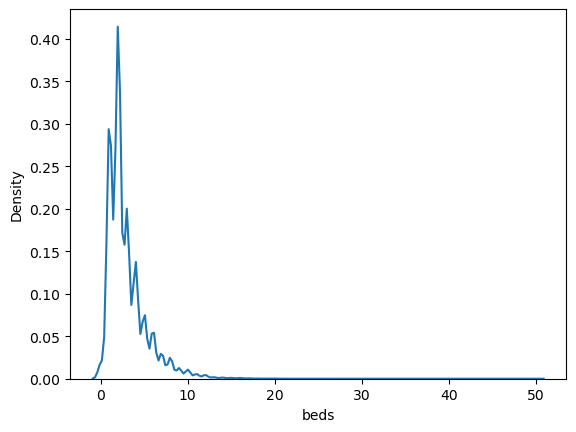

In [115]:
sns.kdeplot(data = df, x= 'beds')
# Right skewed
# shows kernel density distribution of the beds 

<Axes: xlabel='accommodates', ylabel='bedrooms'>

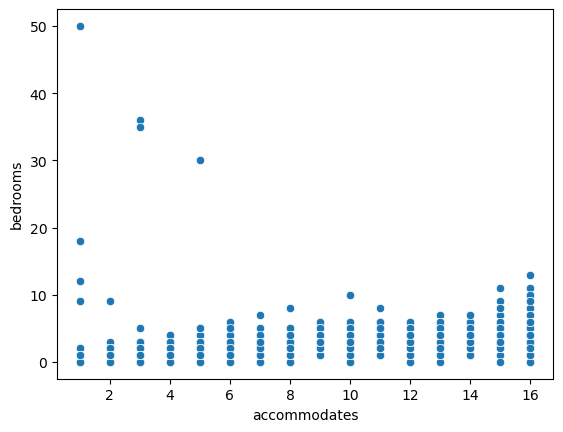

In [116]:
sns.scatterplot(data = df, x = 'accommodates', y = 'bedrooms') 

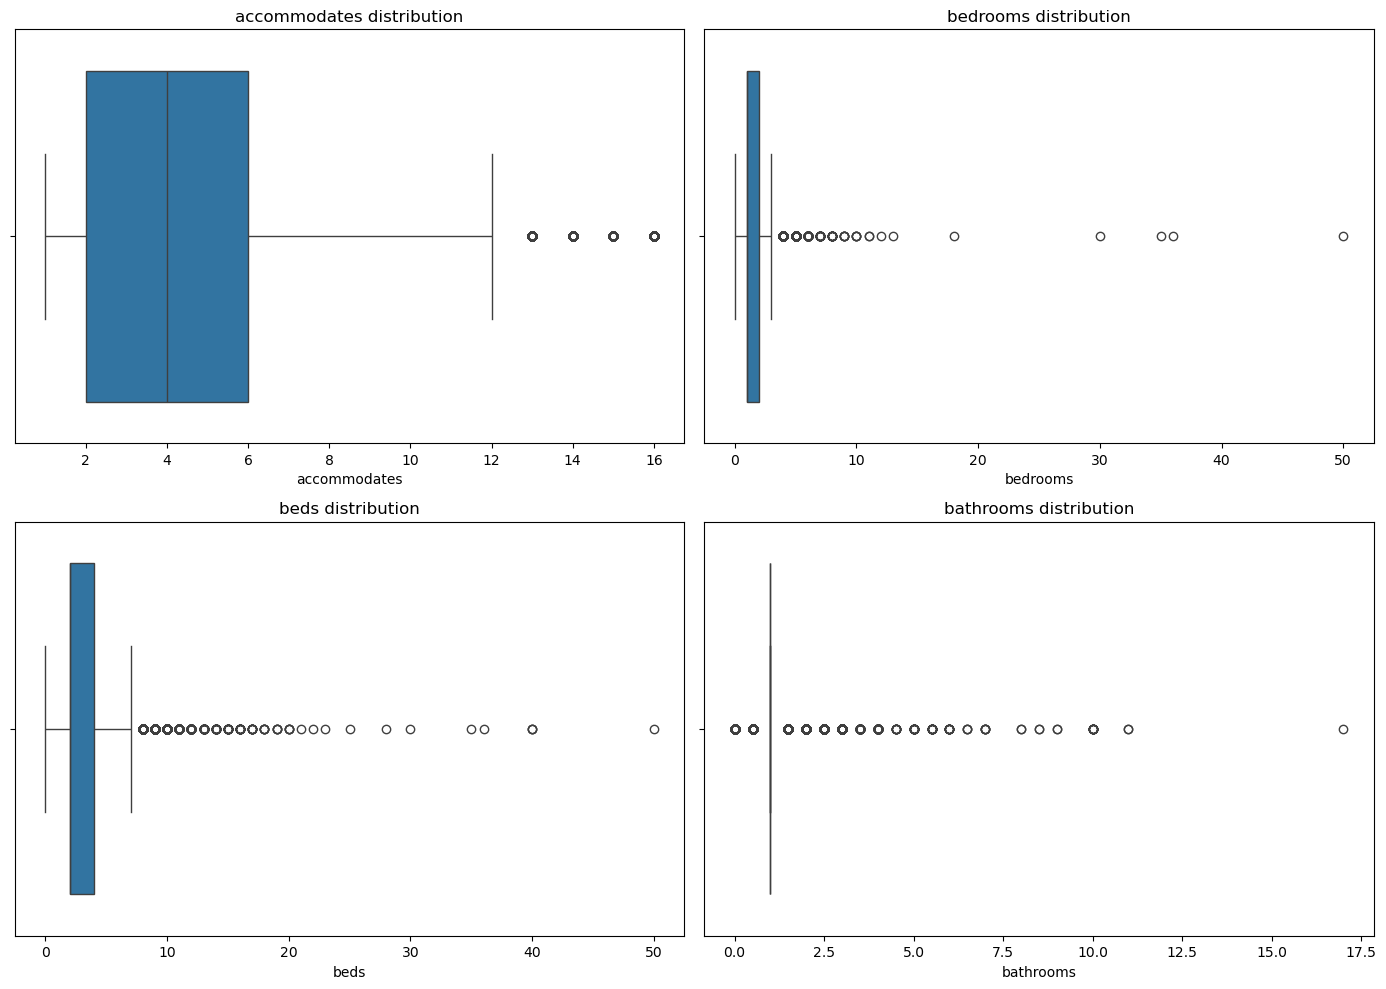

      accommodates  bedrooms  beds  bathrooms
0.90           8.0       3.0   6.0        1.5
0.95          10.0       3.0   7.0        2.0
0.99          16.0       5.0  11.0        3.0
1.00          16.0      50.0  50.0       17.0


In [117]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['accommodates', 'bedrooms', 'beds', 'bathrooms']):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

# Also print percentiles to find sensible caps
print(df[['accommodates', 'bedrooms', 'beds', 'bathrooms']].quantile([0.90, 0.95, 0.99, 1.0]))

In [118]:
# Using the 99th percentile as the cap is standard it removes the top 1% extreme values
# while keeping legitimate large listings. You null them out rather than dropping so KNN can recover sensible values
cols_to_cap = ['accommodates', 'bedrooms', 'beds', 'bathrooms']

for col in cols_to_cap:
    cap = df[col].quantile(0.99)
    print(f"{col} 99th percentile cap: {cap}")
    df.loc[df[col] > cap, col] = np.nan  # null out, don't drop

accommodates 99th percentile cap: 16.0
bedrooms 99th percentile cap: 5.0
beds 99th percentile cap: 11.0
bathrooms 99th percentile cap: 3.0


In [119]:
# Using the 99th percentile as the cap is standard it removes the top 1% extreme values
# while keeping legitimate large listings. You null them out rather than dropping so KNN can recover sensible values
cols_to_cap = ['price']
for col in cols_to_cap:
    cap = df[col].quantile(0.99)
    print(f"{col} 99th percentile cap: {cap}")
    df.loc[df[col] > cap, col] = np.nan  # null out, don't drop

price 99th percentile cap: 148912.9599999988


In [120]:
print(df[df['estimated_occupancy_l365d'].isna()].shape)

(0, 47)


In [121]:
# These are missing at random and are correlated with 
# accommodates, bedrooms, room_type. KNN will use those relationships to make good estimates.
from sklearn.impute import KNNImputer

knn_cols = ['accommodates', 'bedrooms', 'beds', 'bathrooms']
imputer = KNNImputer(n_neighbors=5)
df[knn_cols] = imputer.fit_transform(df[knn_cols])

# Round to sensible values — you can't have 1.4 bedrooms
df['bedrooms'] = df['bedrooms'].round(0)
df['beds'] = df['beds'].round(0)
df['bathrooms'] = df['bathrooms'].round(1)  # 0.5 bathrooms is valid (half bath)

In [123]:
print(df[['accommodates', 'bedrooms', 'beds', 'bathrooms']].isnull().sum())
print(df[['accommodates', 'bedrooms', 'beds', 'bathrooms']].describe())

accommodates    0
bedrooms        0
beds            0
bathrooms       0
dtype: int64
       accommodates      bedrooms          beds     bathrooms
count  27945.000000  27945.000000  27945.000000  27945.000000
mean       4.466380      1.396672      2.847271      1.130481
std        2.934797      0.889627      2.016236      0.368376
min        1.000000      0.000000      0.000000      0.000000
25%        2.000000      1.000000      1.000000      1.000000
50%        4.000000      1.000000      2.000000      1.000000
75%        6.000000      2.000000      4.000000      1.000000
max       16.000000      5.000000     11.000000      3.000000


In [34]:
# host_is_superhost (7.2% missing)
# Superhost status is assigned by Airbnb automatically if it's missing, 
# the host likely hasn't met the criteria yet or is newly joined. Fill with 0

In [124]:
df['host_is_superhost'] = df['host_is_superhost'].fillna(0)

In [125]:
# host_response_time & host_response_rate (2.5% missing)
# These go together if one is missing, both are. Hosts who haven't responded to enough requests won't 
# have a rate calculated by Airbnb. Fill with the mode for response time, median for response rate:

df['host_response_time'] = df['host_response_time'].fillna(df['host_response_time'].mode()[0])
df['host_response_rate'] = df['host_response_rate'].fillna(df['host_response_rate'].median())

In [126]:
# host_acceptance_rate (1.5% missing) Same logicfill with median:

In [127]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].median())

In [128]:
# Are these all missing from the same rows?
host_cols = ['host_since', 'host_has_profile_pic', 'host_total_listings_count', 
             'host_listings_count', 'host_identity_verified']

print(df[host_cols].isnull().all(axis=1).sum())  # rows where ALL are missing

8


In [129]:
# ~8 rows out of 27,945 is negligible. 
# A host profile with no host_since, no pic, 
# no identity verification is essentially an incomplete/ghost listing not useful for analysis:

In [130]:
print(df['has_availability'].value_counts())  # check dominant value first


has_availability
1.0    27826
Name: count, dtype: int64


In [131]:
df['has_availability'] = df['has_availability'].fillna(df['has_availability'].mode()[0])

In [132]:
df.shape

(27945, 47)

In [133]:
# As suggested my the professor dropping the null values in price 
df.dropna(subset=['price'], inplace = True )

In [134]:
# As suggested my the professor dropping the null values in price 
df.dropna(subset=['review_scores_rating'], inplace = True )

In [135]:
# As suggested my the professor dropping the null values in price 
df.dropna(subset=['host_since'], inplace = True )

In [136]:
df.shape

(25217, 47)

### Feature Transformation

In [137]:
# Host tenure
df['host_since'] = pd.to_datetime(df['host_since'])
df['host_tenure_days'] = (pd.Timestamp.today() - df['host_since']).dt.days

# Days since last review
df['last_review'] = pd.to_datetime(df['last_review'])
df['days_since_last_review'] = (pd.Timestamp.today() - df['last_review']).dt.days

In [138]:
# Estimated monthly revenue = price × estimated occupied nights per month
df['estimated_monthly_revenue'] = df['price'] * (df['estimated_occupancy_l365d'] / 12)

# Estimated annual revenue = price × estimated occupied nights per year  
df['estimated_annual_revenue'] = df['price'] * df['estimated_occupancy_l365d']

In [139]:
#  one hot encoding i.e creating dummy variables will need to be careful of unique and shared room and possibly merge them into 
# entire_place 
def categorization(p):
    p = str(p).lower()
    if p.startswith('private room'):
        return 'private_room'
    elif p.startswith('shared room'):
        return 'shared_room'
    elif p.startswith('room in'):
        return 'hotel_style'
    elif any(x in p for x in ['hut', 'treehouse', 'tent', 'barn', 'earthen']):
        return 'unique_stay'
    else:
        return 'entire_place'

df['property_bucket'] = df['property_type'].apply(categorization)    

In [140]:
# Based on geographic location and tourism/commercial significance
central_tokyo = ['Chiyoda Ku', 'Chuo Ku', 'Minato Ku', 'Shinjuku Ku', 'Shibuya Ku']

east_tokyo = ['Taito Ku', 'Sumida Ku', 'Koto Ku', 'Edogawa Ku', 
              'Katsushika Ku', 'Adachi Ku', 'Arakawa Ku']

west_tokyo = ['Suginami Ku', 'Nakano Ku', 'Nerima Ku', 'Itabashi Ku', 
              'Toshima Ku', 'Bunkyo Ku', 'Kita Ku']

south_tokyo = ['Meguro Ku', 'Setagaya Ku', 'Shinagawa Ku', 'Ota Ku']

greater_tokyo = ['Akishima Shi', 'Machida Shi', 'Higashimurayama Shi', 
                 'Kokubunji Shi', 'Hino Shi', 'Mitaka Shi', 'Hachioji Shi', 
                 'Kodaira Shi', 'Fuchu Shi', 'Fussa Shi', 'Tama Shi', 
                 'Komae Shi', 'Chofu Shi', 'Akiruno Shi', 'Koganei Shi', 
                 'Nishitokyo Shi', 'Ome Shi', 'Higashiyamato Shi', 
                 'Hamura Shi', 'Tachikawa Shi', 'Musashino Shi', 
                 'Kunitachi Shi', 'Okutama Machi', 'Hinohara Mura', 
                 'Kiyose Shi', 'Inagi Shi']

def bucket_neighbourhood(n):
    if n in central_tokyo:
        return 'Central Tokyo'
    elif n in east_tokyo:
        return 'East Tokyo'
    elif n in west_tokyo:
        return 'West Tokyo'
    elif n in south_tokyo:
        return 'South Tokyo'
    else:
        return 'Greater Tokyo'

df['neighbourhood_bucket'] = df['neighbourhood_cleansed'].apply(bucket_neighbourhood)

# Verify no neighbourhood was missed
print(df['neighbourhood_bucket'].value_counts())
print(f"\nAny unmapped: {df['neighbourhood_bucket'].isna().sum()}")

neighbourhood_bucket
East Tokyo       8733
Central Tokyo    7769
West Tokyo       5696
South Tokyo      2501
Greater Tokyo     518
Name: count, dtype: int64

Any unmapped: 0


In [141]:
df['price_log'] = np.log1p(df['price'])

In [142]:
df['estimated_annual_revenue_log'] = np.log1p(df[['estimated_annual_revenue']])

In [143]:
df['estimated_monthly_revenue_log'] = np.log1p(df['estimated_monthly_revenue'])

In [144]:
revised_missing = df.isnull().sum()/len(df) *100

In [145]:
revised_missing

id                                 0.000000
host_id                            0.000000
host_since                         0.000000
host_response_time                 0.000000
host_response_rate                 0.000000
host_acceptance_rate               0.000000
host_is_superhost                  0.000000
host_listings_count                0.000000
host_total_listings_count          0.000000
host_has_profile_pic               0.000000
host_identity_verified             0.000000
neighbourhood_cleansed             0.000000
property_type                      0.000000
room_type                          0.000000
accommodates                       0.000000
bathrooms                          0.000000
bedrooms                           0.000000
beds                               0.000000
amenities                          0.000000
price                              0.000000
minimum_nights                     0.000000
maximum_nights                     0.000000
has_availability                

## EDA
Focus the story around- 
What drives price? room_type, neighbourhood, accommodates, amenities, superhost
What drives satisfaction? response time, superhost, cleanliness, location score
What drives revenue? price + occupancy + availability + neighbourhood

### Univariate Analysis (Categorical)
count, frequency, boxplot, histogram, probability distribution

In [146]:
df.columns

Index(['id', 'host_id', 'host_since', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable',
       'calculated_host_list

<Axes: xlabel='property_bucket', ylabel='count'>

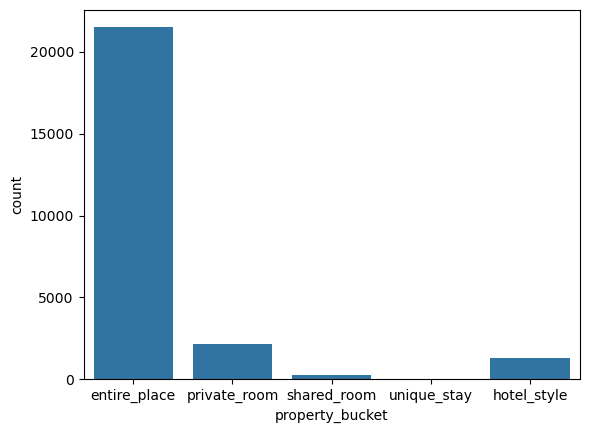

In [147]:
sns.countplot(data = df, x = df['property_bucket'])
# dwarfism 
# dominant by entire place 

<Axes: xlabel='room_type', ylabel='count'>

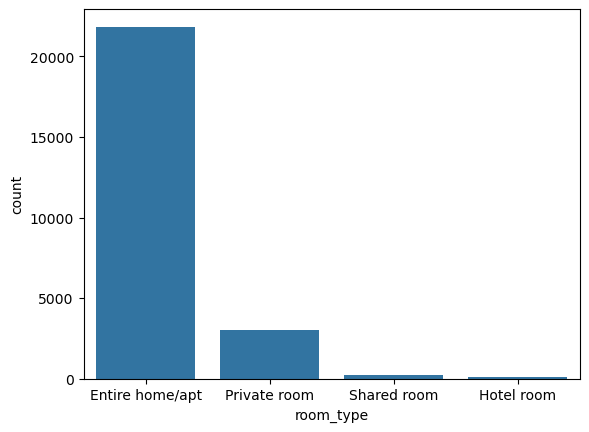

In [148]:
sns.countplot(data = df , x = df['room_type'])
# dominant by entire home/apt 

In [149]:
#sns.countplot(data = df , x = df['neighbourhood_cleansed'])
df['neighbourhood_cleansed'].unique()

array(['Sumida Ku', 'Kita Ku', 'Shibuya Ku', 'Setagaya Ku', 'Adachi Ku',
       'Meguro Ku', 'Katsushika Ku', 'Shinjuku Ku', 'Toshima Ku',
       'Shinagawa Ku', 'Minato Ku', 'Ota Ku', 'Akishima Shi', 'Bunkyo Ku',
       'Itabashi Ku', 'Taito Ku', 'Edogawa Ku', 'Arakawa Ku',
       'Machida Shi', 'Nakano Ku', 'Suginami Ku', 'Higashimurayama Shi',
       'Koto Ku', 'Kokubunji Shi', 'Hino Shi', 'Mitaka Shi',
       'Hachioji Shi', 'Nerima Ku', 'Fuchu Shi', 'Fussa Shi', 'Komae Shi',
       'Chofu Shi', 'Chiyoda Ku', 'Koganei Shi', 'Nishitokyo Shi',
       'Chuo Ku', 'Kodaira Shi', 'Ome Shi', 'Higashiyamato Shi',
       'Hamura Shi', 'Tachikawa Shi', 'Musashino Shi', 'Akiruno Shi',
       'Tama Shi', 'Kunitachi Shi', 'Okutama Machi', 'Hinohara Mura',
       'Kiyose Shi', 'Inagi Shi'], dtype=object)

<Axes: xlabel='host_is_superhost', ylabel='count'>

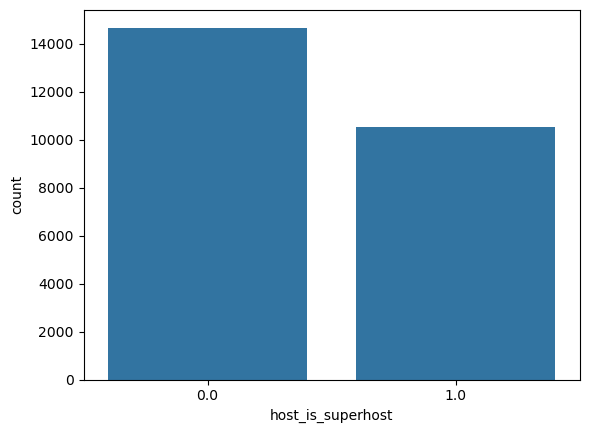

In [150]:
sns.countplot(data = df , x = df['host_is_superhost'])


<Axes: xlabel='instant_bookable', ylabel='count'>

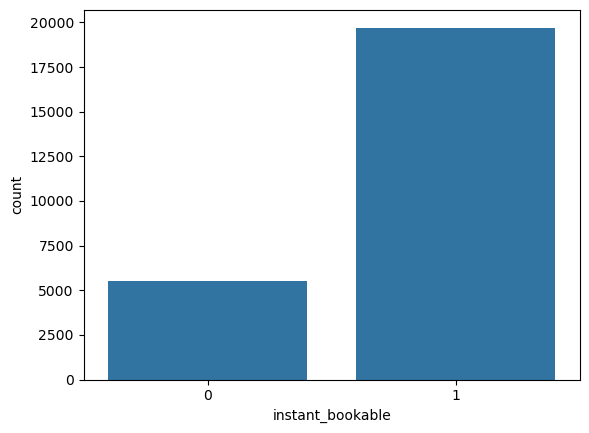

In [151]:
sns.countplot(data = df , x = df['instant_bookable'])
# Dominant by True value 

<Axes: xlabel='host_identity_verified', ylabel='count'>

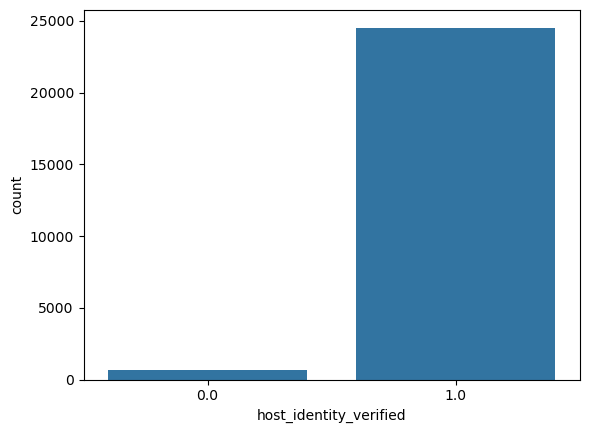

In [152]:
sns.countplot(data = df , x = df['host_identity_verified'])
# Dominant by True value 

<Axes: xlabel='host_has_profile_pic', ylabel='count'>

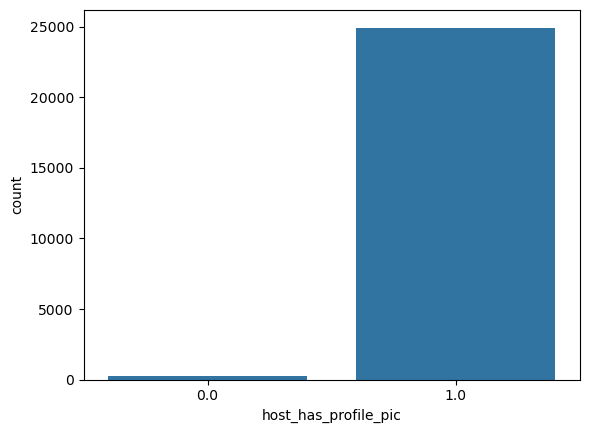

In [153]:
sns.countplot(data = df , x = df['host_has_profile_pic'])
# Dominant by True value 

<Axes: xlabel='has_review', ylabel='count'>

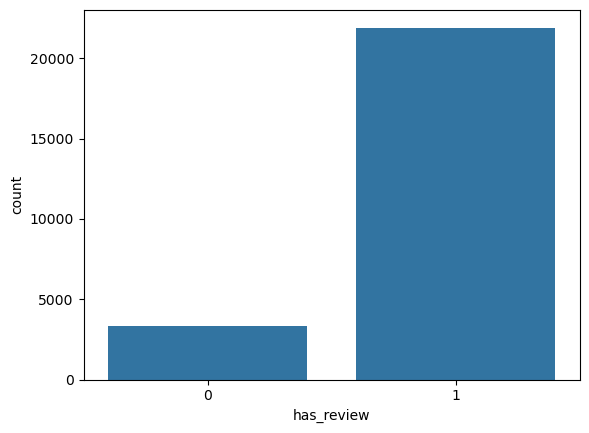

In [154]:
sns.countplot(data = df , x = df['has_review'])
# Dominant by True value 

### Univariate Analysis (Numeric)

In [155]:
# price, accommodates, bedrooms, bathrooms, beds,
# count_amenities, host_tenure_days, host_listings_count,
# minimum_nights, review_scores_rating,
# estimated_annual_revenue, estimated_occupancy_l365d

In [156]:
print(df['price'].quantile([0.90, 0.95, 0.99, 1.0]))

0.90     37220.6
0.95     48000.0
0.99     82266.8
1.00    148624.0
Name: price, dtype: float64


<Axes: xlabel='price_log', ylabel='Density'>

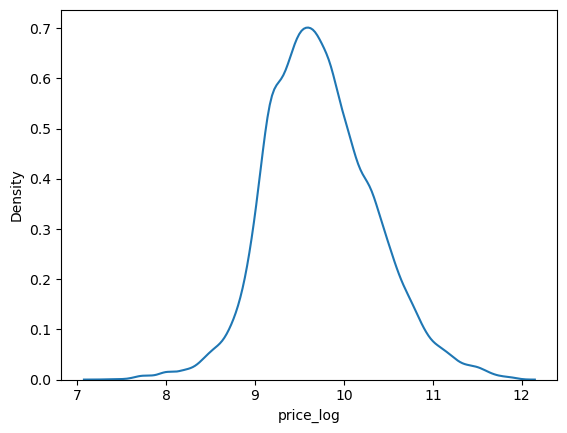

In [157]:
sns.kdeplot(df['price_log'])

<Axes: xlabel='estimated_monthly_revenue_log', ylabel='Density'>

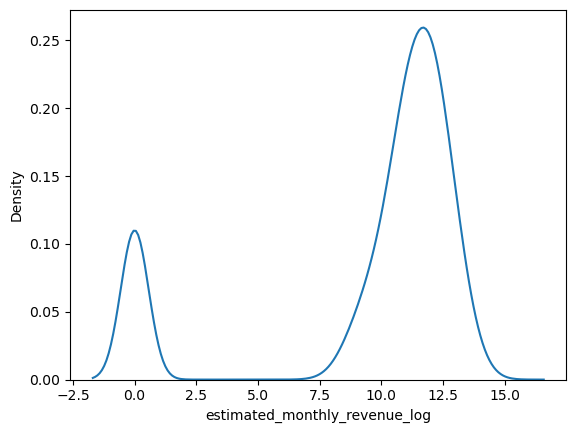

In [158]:
sns.kdeplot(df['estimated_monthly_revenue_log'])

(array([ 1404.,     0., 16582.,     0.,  4114.,     0.,  2012.,     0.,
          918.,   187.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

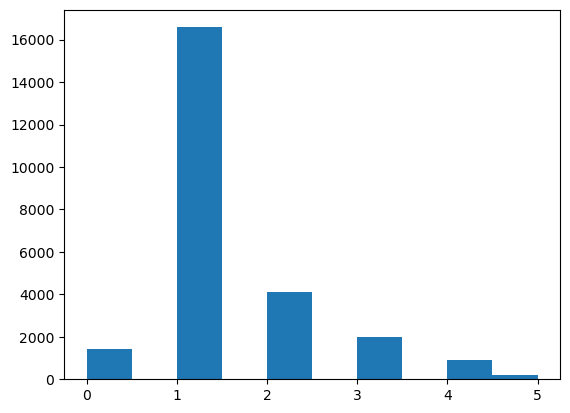

In [159]:
plt.hist(df['bedrooms'])
# bedroom 1 is dominant 

(array([3.3130e+03, 0.0000e+00, 2.4000e+01, 1.0000e+00, 3.0000e+01,
        1.4000e+01, 1.5300e+02, 1.9400e+02, 2.2270e+03, 1.9261e+04]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

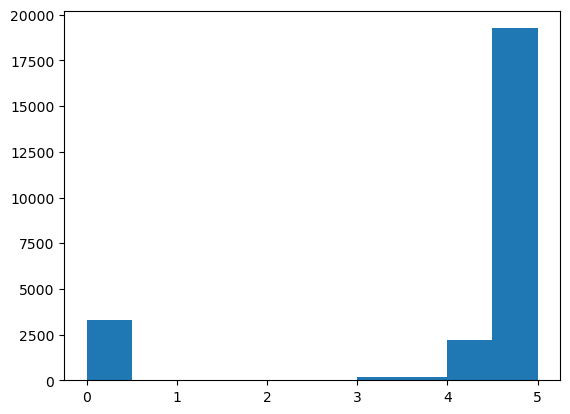

In [160]:
plt.hist(df['review_scores_rating'])
# left skewed data, this indicates mostly the ratings are at the higher end 

(array([20592.,  2780.,  1152.,   463.,    63.,     0.,     0.,     0.,
            0.,   167.]),
 array([  1. ,  51.1, 101.2, 151.3, 201.4, 251.5, 301.6, 351.7, 401.8,
        451.9, 502. ]),
 <BarContainer object of 10 artists>)

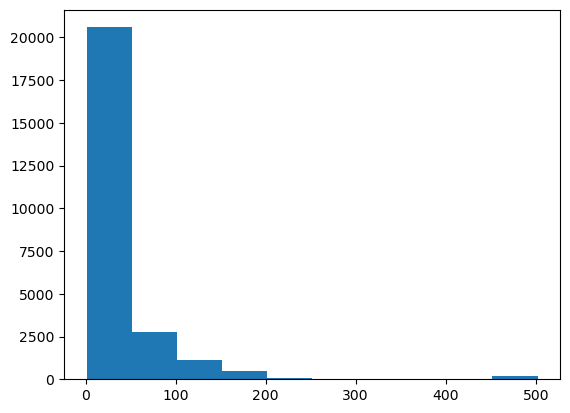

In [161]:
plt.hist(df['host_listings_count'])
# Mostly the listings are concentrated in the range 0-100 

(array([4992., 6849., 1304., 2050., 3786., 2082., 2957.,  842.,  319.,
          36.]),
 array([ 211. ,  750.6, 1290.2, 1829.8, 2369.4, 2909. , 3448.6, 3988.2,
        4527.8, 5067.4, 5607. ]),
 <BarContainer object of 10 artists>)

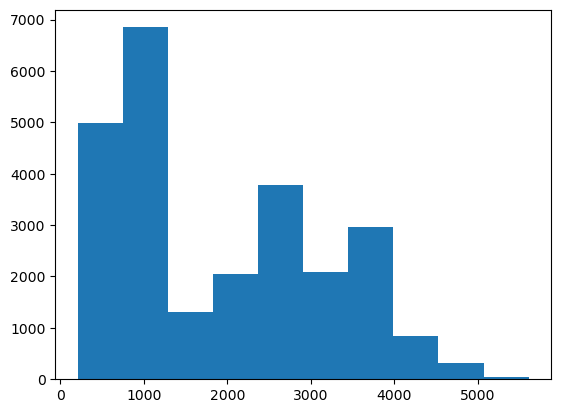

In [162]:

plt.hist(df['host_tenure_days'])
# Most of the host have been on Airbnb platform ~3-4 years period, with few > 4 years and very few >15 years

### Bivariate — Relationship Between Two Variables

<Axes: xlabel='room_type', ylabel='price_log'>

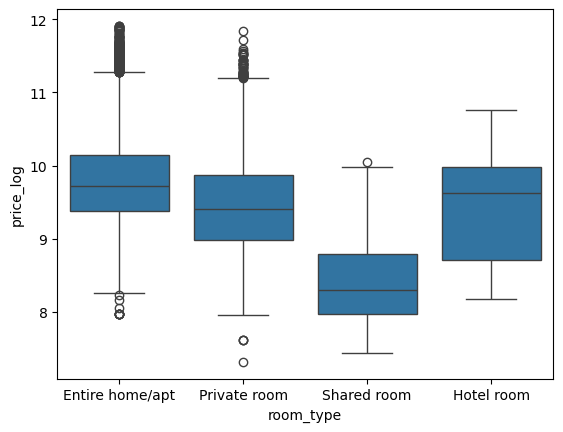

In [163]:
## price vs room_type 
sns.boxplot(data = df, x = df['room_type'], y=df['price_log'])
# median (50 percentile) is ~ 9 i.e highest for Entire home apt 
# followed by hotel room, private room 

<Axes: xlabel='property_bucket', ylabel='price_log'>

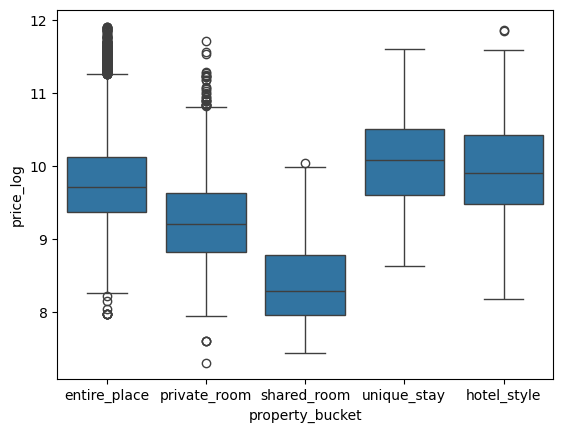

In [164]:
sns.boxplot(data = df, x = df['property_bucket'], y=df['price_log'])
# unique stay followed by hotel style have median 50 percentile ~11 followed by hotel style 

<Axes: xlabel='neighbourhood_bucket', ylabel='price_log'>

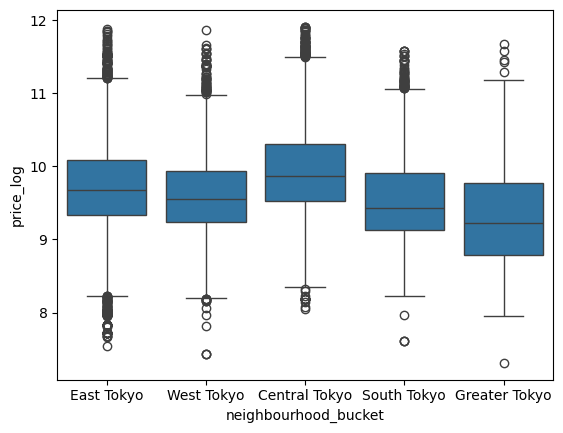

In [165]:
sns.boxplot(data = df, x = df['neighbourhood_bucket'], y=df['price_log'])
# central tokyo has the highest median with approx 10 

<Axes: xlabel='bedrooms', ylabel='price_log'>

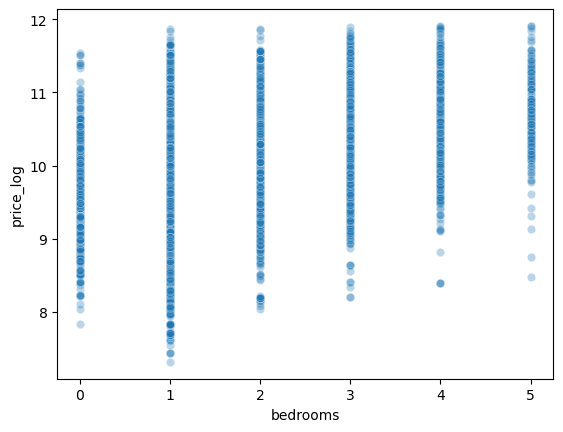

In [166]:
sns.scatterplot(data=df, x= 'bedrooms', y='price_log', alpha=0.3)

<Axes: xlabel='count_amenities', ylabel='price_log'>

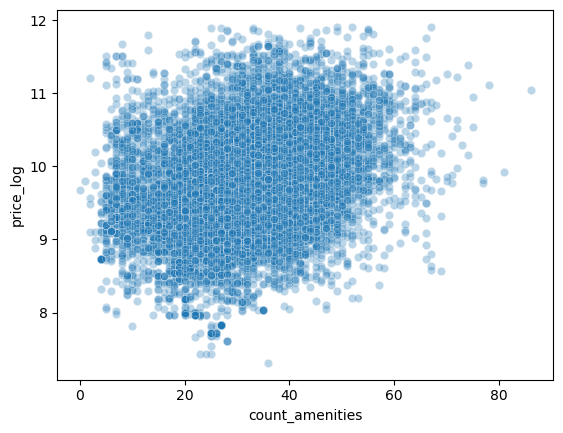

In [167]:
sns.scatterplot(data=df, x= 'count_amenities', y='price_log', alpha=0.3)
# positve relationship, higher the count of amenities higher the price 

<Axes: xlabel='accommodates', ylabel='price_log'>

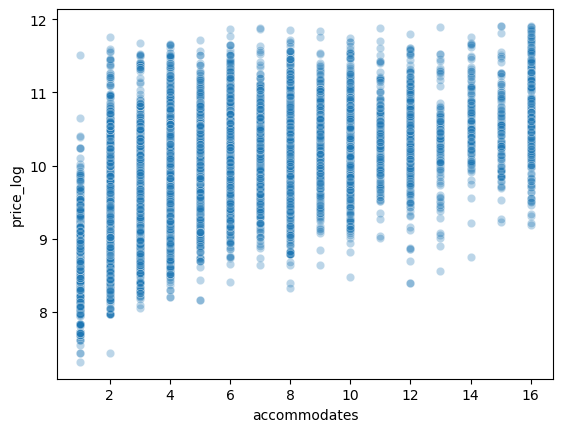

In [168]:
sns.scatterplot(data=df, x= 'accommodates', y='price_log', alpha=0.3)

<Axes: xlabel='minimum_nights', ylabel='price_log'>

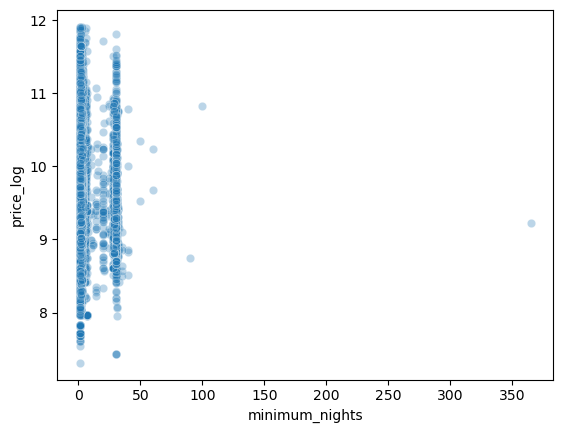

In [169]:
sns.scatterplot(data=df, x= 'minimum_nights', y='price_log', alpha=0.3)
# There are certain records where the minimum_nights equal >= 200, hence we are seeing outlier at 350 

<Axes: xlabel='host_is_superhost', ylabel='review_scores_rating'>

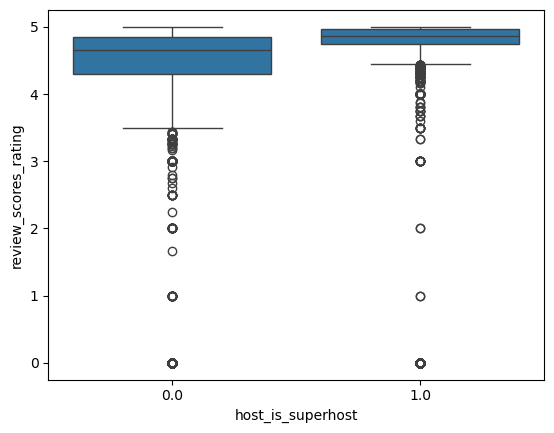

In [170]:
sns.boxplot(data = df , x = 'host_is_superhost', y = 'review_scores_rating')
# host_is_superhost equals true has ratings mostly with the median ~5 or lower 

<Axes: xlabel='room_type', ylabel='review_scores_rating'>

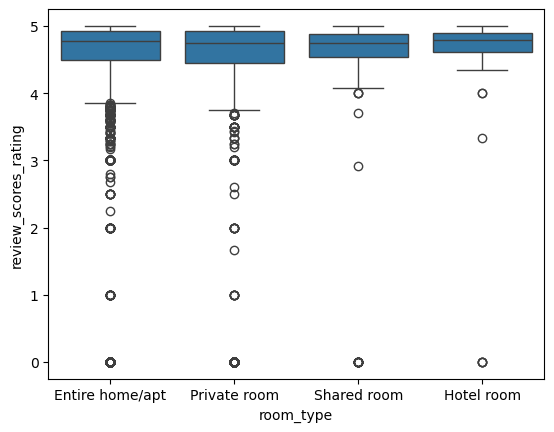

In [171]:
sns.boxplot(data = df , x = 'room_type', y = 'review_scores_rating')
# median rating for all of the room type is ~ 4.8 to ~5

<Axes: xlabel='count_amenities', ylabel='review_scores_rating'>

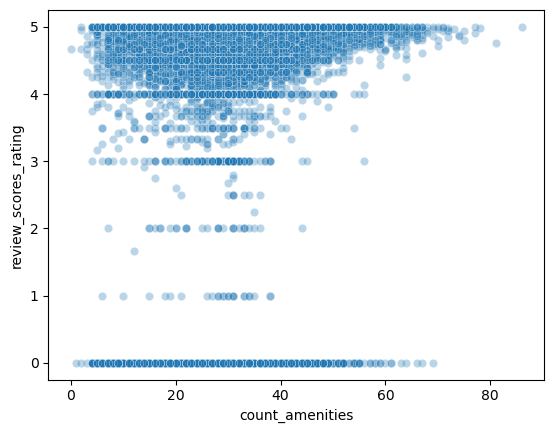

In [172]:
sns.scatterplot(data=df, x= 'count_amenities', y= 'review_scores_rating', alpha=0.3)
# Does not seem to be any realtionship 

### Multivariate — Multiple Variables

<Axes: xlabel='host_tenure_days', ylabel='review_scores_rating'>

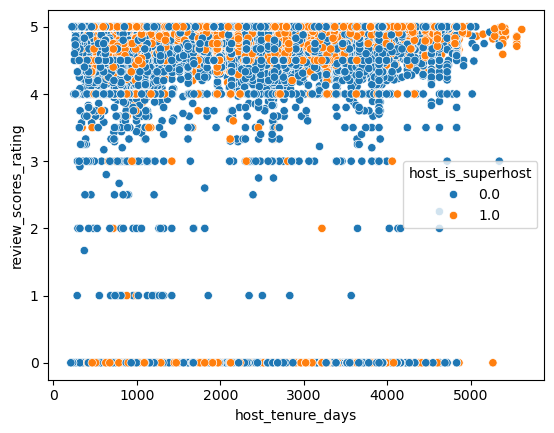

In [173]:
sns.scatterplot(data=df, x= 'host_tenure_days', y= 'review_scores_rating', hue = 'host_is_superhost')
# Does not seem to be any realtionship 

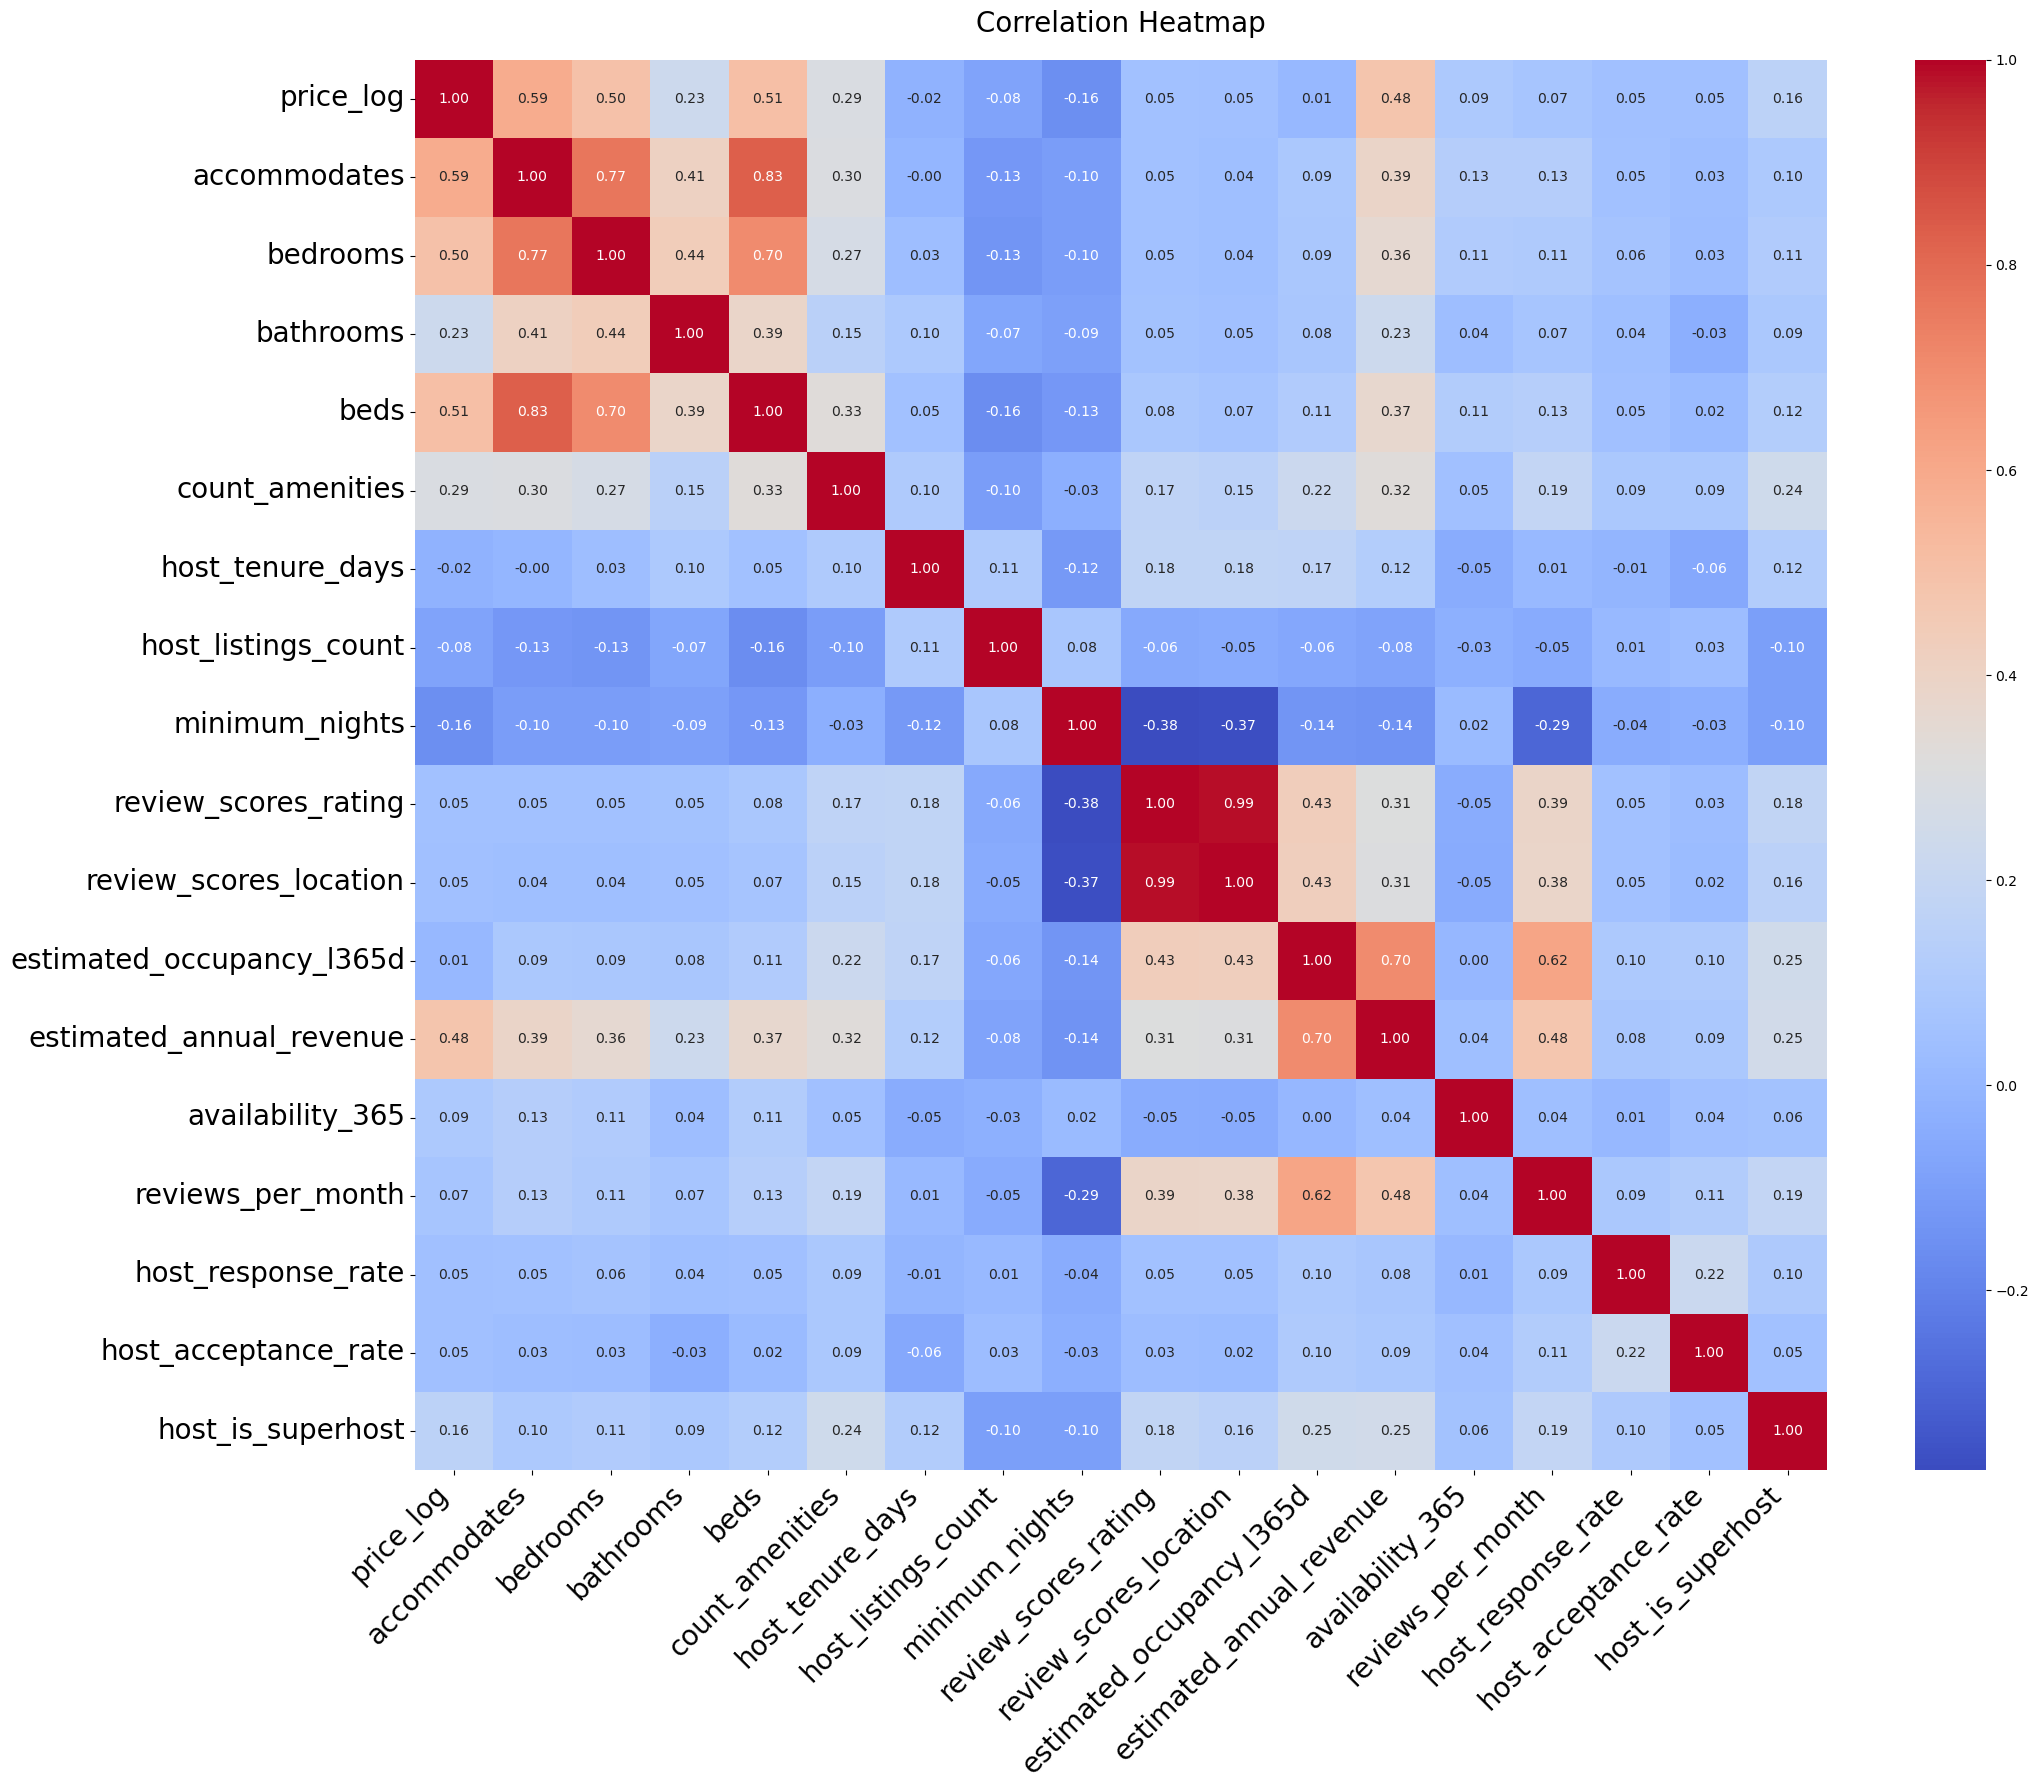

In [174]:
plt.figure(figsize=(22, 18))  # increase figure size

numeric_cols = ['price_log', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
                'count_amenities', 'host_tenure_days', 'host_listings_count',
                'minimum_nights', 'review_scores_rating',
                'review_scores_location',
                'estimated_occupancy_l365d', 'estimated_annual_revenue',
                'availability_365', 'reviews_per_month', 'host_response_rate',
                'host_acceptance_rate', 'host_is_superhost']

sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.xticks(rotation=45, ha='right', fontsize= 20)  # rotate x labels
plt.yticks(fontsize= 20)                            # y label font size
plt.title('Correlation Heatmap', fontsize= 20, pad=20)
plt.tight_layout()
plt.show()


In [175]:
df.to_csv('/users/yasmeenkarachiwala/downloads/final_tokyo_listing_updated_april_26.csv')

In [176]:
df.shape

(25217, 56)

In [177]:
df['price'].isna().sum()

np.int64(0)

In [178]:
df['review_scores_rating'].isna().sum()

np.int64(0)